In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binomtest

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

customers = pd.read_parquet(
    DATA_DIR / "customer_retention_dataset.parquet"
)

print(customers.shape)
display(customers.head())
display(customers.dtypes)

(5281, 18)


,customer_id,first_order_id,first_order_date,first_order_value,first_order_quantity,first_order_unique_products,first_order_product_lines,first_order_average_item_price,first_order_country,first_order_weekday,first_order_month,first_order_hour,first_order_is_weekend,second_order_date,days_to_second_order,available_followup_days,has_full_90d_followup,repeat_within_90d
0,12346,Year 2009-2010_491725,2009-12-14 08:34:00,45.00,10,1,1,4.500000,United Kingdom,Monday,12,8,False,2009-12-14 11:00:00,0.101389,725.177778,True,1
1,12347,Year 2009-2010_529924,2010-10-31 14:20:00,611.53,509,40,40,1.201434,Iceland,Sunday,10,14,True,2010-12-07 14:57:00,37.025694,403.937500,True,1
2,12348,Year 2009-2010_524140,2010-09-27 14:59:00,222.16,373,20,20,0.595603,Finland,Monday,9,14,False,2010-12-16 19:09:00,80.173611,437.910417,True,1
3,12349,Year 2009-2010_506394,2010-04-29 13:20:00,1068.52,473,46,46,2.259027,Italy,Thursday,4,13,False,2010-05-18 09:57:00,18.859028,588.979167,True,1
4,12350,Year 2010-2011_543037,2011-02-02 16:01:00,334.40,197,17,17,1.697462,Norway,Wednesday,2,16,False,NaT,NaN,309.867361,True,0


customer_id                       string[python]
first_order_id                    string[python]
first_order_date                  datetime64[ns]
first_order_value                        float64
first_order_quantity                       int64
first_order_unique_products                int64
first_order_product_lines                  int64
first_order_average_item_price           float64
first_order_country               string[python]
first_order_weekday                       object
first_order_month                          int32
first_order_hour                           int32
first_order_is_weekend                      bool
second_order_date                 datetime64[ns]
days_to_second_order                     float64
available_followup_days                  float64
has_full_90d_followup                       bool
repeat_within_90d                          int32
dtype: object

In [3]:
assert customers["customer_id"].is_unique
assert customers["repeat_within_90d"].isin([0, 1]).all()
assert customers["available_followup_days"].ge(90).all()

In [4]:
n_customers = len(customers)
n_repeat = customers["repeat_within_90d"].sum()
repeat_rate = customers["repeat_within_90d"].mean()

confidence_interval = binomtest(
    k=n_repeat,
    n=n_customers
).proportion_ci(
    confidence_level=0.95,
    method="wilson"
)

print(f"Eligible customers: {n_customers:,}")
print(f"Repeat customers: {n_repeat:,}")
print(f"90-day repeat rate: {repeat_rate:.2%}")
print(
    f"95% CI: "
    f"[{confidence_interval.low:.2%}, "
    f"{confidence_interval.high:.2%}]"
)

Eligible customers: 5,281
Repeat customers: 2,475
90-day repeat rate: 46.87%
95% CI: [45.52%, 48.21%]


The estimated 90-day repeat rate among eligible identifiable customers is 46.87%, with a 95% confidence interval of approximately [45.52%, 48.21%].

In [5]:
feature_columns = [
    "first_order_value",
    "first_order_quantity",
    "first_order_unique_products",
    "first_order_product_lines",
    "first_order_average_item_price",
]

customers[feature_columns].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
first_order_value,5281.0,412.016877,756.957581,1.3000,21.000000,72.900000,166.240000,293.530000,446.620000,1056.630000,2330.136,33167.8
first_order_quantity,5281.0,259.459572,1294.584843,1.0000,1.000000,21.000000,79.000000,150.000000,277.000000,675.000000,1560.200,87167.0
first_order_unique_products,5281.0,23.722590,22.457774,1.0000,1.000000,2.000000,9.000000,18.000000,31.000000,65.000000,111.000,250.0
first_order_product_lines,5281.0,24.078394,23.105774,1.0000,1.000000,2.000000,9.000000,18.000000,31.000000,66.000000,115.000,251.0
first_order_average_item_price,5281.0,7.788863,182.401885,0.1363,0.457813,0.819945,1.405436,1.895838,2.611682,5.269048,22.255,10953.5


In [6]:
distribution_summary = customers[feature_columns].agg(
    ["mean", "median", "std", "min", "max"]
).T

distribution_summary

,mean,median,std,min,max
first_order_value,412.016877,293.530000,756.957581,1.3000,33167.8
first_order_quantity,259.459572,150.000000,1294.584843,1.0000,87167.0
first_order_unique_products,23.722590,18.000000,22.457774,1.0000,250.0
first_order_product_lines,24.078394,18.000000,23.105774,1.0000,251.0
first_order_average_item_price,7.788863,1.895838,182.401885,0.1363,10953.5


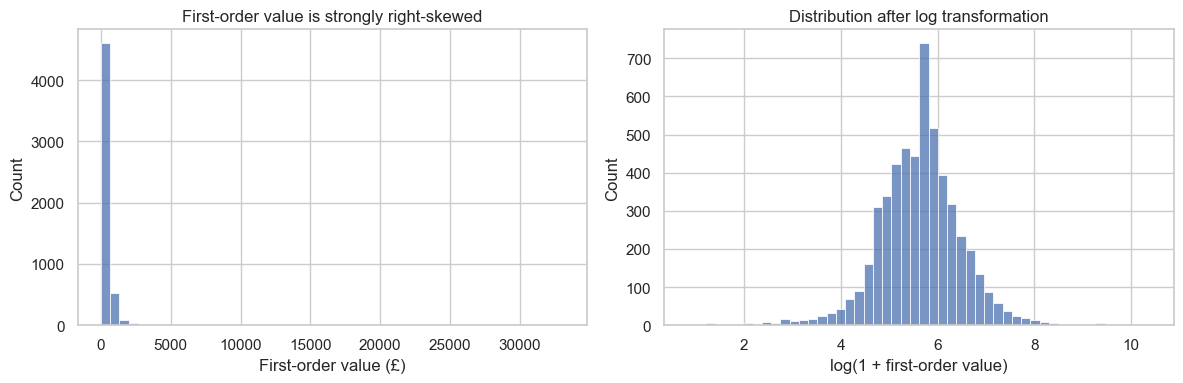

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=customers,
    x="first_order_value",
    bins=50,
    ax=axes[0]
)

axes[0].set_title("First-order value is strongly right-skewed")
axes[0].set_xlabel("First-order value (£)")

sns.histplot(
    np.log1p(customers["first_order_value"]),
    bins=50,
    ax=axes[1]
)

axes[1].set_title("Distribution after log transformation")
axes[1].set_xlabel("log(1 + first-order value)")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "first_order_value_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [8]:
returned = customers.loc[
    customers["second_order_date"].notna()
].copy()

returned["days_to_second_order"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)

count    4045.000000
mean       99.915294
std       114.203031
min         0.000000
10%         2.881389
25%        20.928472
50%        58.918056
75%       134.159028
90%       263.056111
max       714.152083
Name: days_to_second_order, dtype: float64

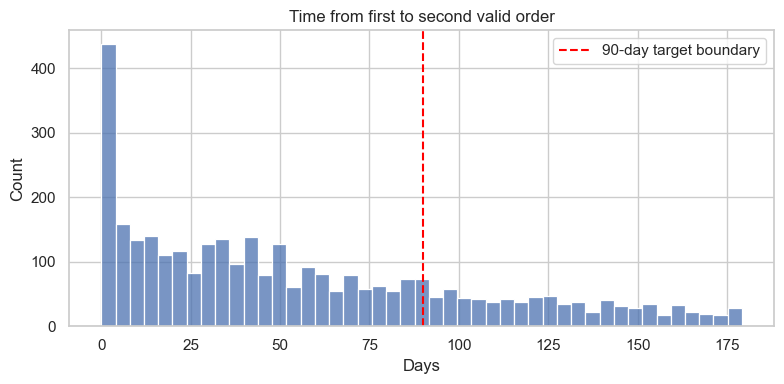

In [9]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=returned[
        returned["days_to_second_order"].between(0, 180)
    ],
    x="days_to_second_order",
    bins=45
)

plt.axvline(
    90,
    color="red",
    linestyle="--",
    label="90-day target boundary"
)

plt.title("Time from first to second valid order")
plt.xlabel("Days")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "days_to_second_order.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
def segment_repeat_summary(data, segment):
    summary = (
        data.groupby(segment, observed=True)
        .agg(
            customers=("customer_id", "size"),
            repeat_customers=("repeat_within_90d", "sum"),
            repeat_rate=("repeat_within_90d", "mean"),
        )
        .reset_index()
    )

    intervals = summary.apply(
        lambda row: binomtest(
            int(row["repeat_customers"]),
            int(row["customers"])
        ).proportion_ci(
            confidence_level=0.95,
            method="wilson"
        ),
        axis=1
    )

    summary["ci_low"] = [interval.low for interval in intervals]
    summary["ci_high"] = [interval.high for interval in intervals]

    return summary

In [11]:
customers["first_order_value_band"] = pd.qcut(
    customers["first_order_value"],
    q=5,
    duplicates="drop"
)

value_summary = segment_repeat_summary(
    customers,
    "first_order_value_band"
)

value_summary

,first_order_value_band,customers,repeat_customers,repeat_rate,ci_low,ci_high
0,"(1.2990000000000002, 147.27]",1057,375,0.354778,0.326508,0.384099
1,"(147.27, 233.4]",1056,434,0.410985,0.381684,0.440931
2,"(233.4, 327.95]",1056,509,0.482008,0.451990,0.512156
3,"(327.95, 518.35]",1056,533,0.504735,0.474617,0.534819
4,"(518.35, 33167.8]",1056,624,0.590909,0.560977,0.620182


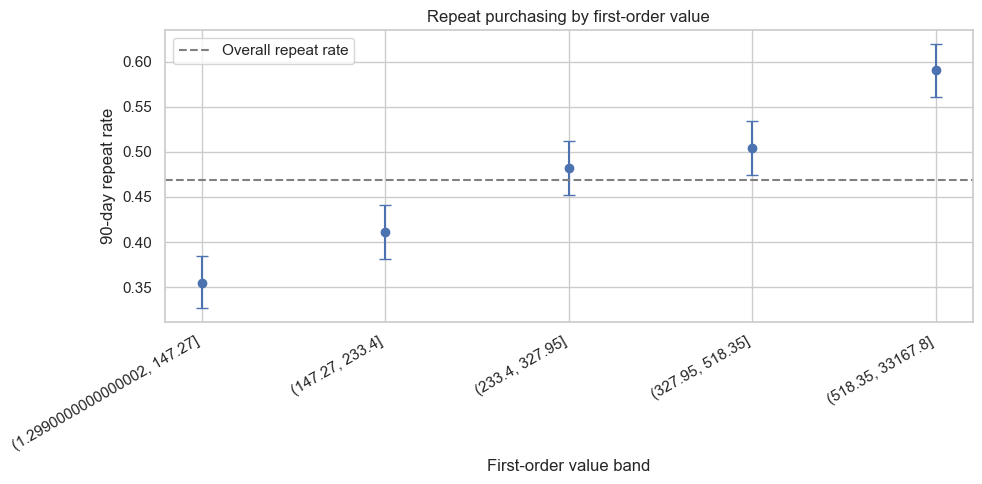

In [12]:
plt.figure(figsize=(10, 5))

x = np.arange(len(value_summary))

plt.errorbar(
    x=x,
    y=value_summary["repeat_rate"],
    yerr=[
        value_summary["repeat_rate"] - value_summary["ci_low"],
        value_summary["ci_high"] - value_summary["repeat_rate"],
    ],
    fmt="o",
    capsize=4
)

plt.xticks(
    x,
    value_summary["first_order_value_band"].astype(str),
    rotation=30,
    ha="right"
)

plt.axhline(
    repeat_rate,
    color="grey",
    linestyle="--",
    label="Overall repeat rate"
)

plt.ylabel("90-day repeat rate")
plt.xlabel("First-order value band")
plt.title("Repeat purchasing by first-order value")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "repeat_rate_by_order_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
customers["product_diversity_band"] = pd.qcut(
    customers["first_order_unique_products"],
    q=5,
    duplicates="drop"
)

diversity_summary = segment_repeat_summary(
    customers,
    "product_diversity_band"
)

diversity_summary

,product_diversity_band,customers,repeat_customers,repeat_rate,ci_low,ci_high
0,"(0.999, 7.0]",1058,428,0.404537,0.375360,0.434405
1,"(7.0, 14.0]",1062,465,0.437853,0.408292,0.467862
2,"(14.0, 22.0]",1154,531,0.460139,0.431562,0.488980
3,"(22.0, 35.0]",953,466,0.488982,0.457353,0.520700
4,"(35.0, 250.0]",1054,585,0.555028,0.524880,0.584777


In [14]:
customers["first_order_cohort"] = (
    customers["first_order_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

cohort_summary = segment_repeat_summary(
    customers,
    "first_order_cohort"
)

cohort_summary

,first_order_cohort,customers,repeat_customers,repeat_rate,ci_low,ci_high
0,2009-12-01,955,583,0.610471,0.579160,0.640898
1,2010-01-01,383,200,0.522193,0.472196,0.571750
2,2010-02-01,374,197,0.526738,0.476122,0.576810
3,2010-03-01,443,195,0.440181,0.394665,0.486725
4,2010-04-01,294,120,0.408163,0.353517,0.465178
5,2010-05-01,254,93,0.366142,0.309300,0.426972
6,2010-06-01,270,107,0.396296,0.339801,0.455702
7,2010-07-01,186,83,0.446237,0.376603,0.518046
8,2010-08-01,162,87,0.537037,0.460286,0.612073
9,2010-09-01,243,112,0.460905,0.399327,0.523701


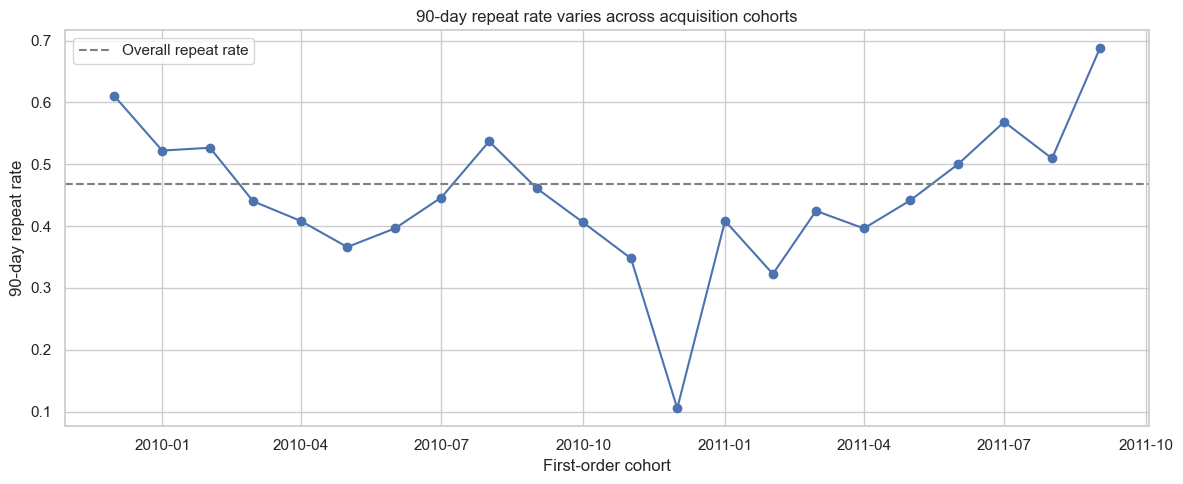

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    cohort_summary["first_order_cohort"],
    cohort_summary["repeat_rate"],
    marker="o"
)

ax1.axhline(
    repeat_rate,
    color="grey",
    linestyle="--",
    label="Overall repeat rate"
)

ax1.set_ylabel("90-day repeat rate")
ax1.set_xlabel("First-order cohort")
ax1.set_title("90-day repeat rate varies across acquisition cohorts")
ax1.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "repeat_rate_by_cohort.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
cohort_summary[
    [
        "first_order_cohort",
        "customers",
        "repeat_rate",
        "ci_low",
        "ci_high",
    ]
]

,first_order_cohort,customers,repeat_rate,ci_low,ci_high
0,2009-12-01,955,0.610471,0.579160,0.640898
1,2010-01-01,383,0.522193,0.472196,0.571750
2,2010-02-01,374,0.526738,0.476122,0.576810
3,2010-03-01,443,0.440181,0.394665,0.486725
4,2010-04-01,294,0.408163,0.353517,0.465178
5,2010-05-01,254,0.366142,0.309300,0.426972
6,2010-06-01,270,0.396296,0.339801,0.455702
7,2010-07-01,186,0.446237,0.376603,0.518046
8,2010-08-01,162,0.537037,0.460286,0.612073
9,2010-09-01,243,0.460905,0.399327,0.523701


In [17]:
country_summary = segment_repeat_summary(
    customers,
    "first_order_country"
)

country_summary = country_summary[
    country_summary["customers"] >= 100
].sort_values(
    "repeat_rate",
    ascending=False
)

country_summary

,first_order_country,customers,repeat_customers,repeat_rate,ci_low,ci_high
38,United Kingdom,4813,2243,0.46603,0.451969,0.480144


In [18]:
value_cutoff = customers["first_order_value"].quantile(0.99)

non_extreme_customers = customers[
    customers["first_order_value"] <= value_cutoff
]

sensitivity_summary = pd.DataFrame({
    "sample": [
        "All eligible customers",
        "Exclude top 1% first-order values",
    ],
    "customers": [
        len(customers),
        len(non_extreme_customers),
    ],
    "repeat_rate": [
        customers["repeat_within_90d"].mean(),
        non_extreme_customers["repeat_within_90d"].mean(),
    ],
})

sensitivity_summary

,sample,customers,repeat_rate
0,All eligible customers,5281,0.468661
1,Exclude top 1% first-order values,5228,0.465570


## Preliminary findings

1. The observed 90-day repeat rate was X%, with a 95% confidence
   interval of [45.52%, 48.21%].

2. Repeat rates were higher/lower across first-order value bands,
   although the relationship was monotonically increasing.

3. Retention varied across acquisition cohorts, suggesting that
   temporal validation is necessary.

## Caveats

1. Customers without recorded customer IDs were excluded.

2. Segment comparisons are observational associations and should not
   be interpreted causally.

3. The customer population includes possible wholesale customers,
   which may limit generalisability to ordinary retail consumers.